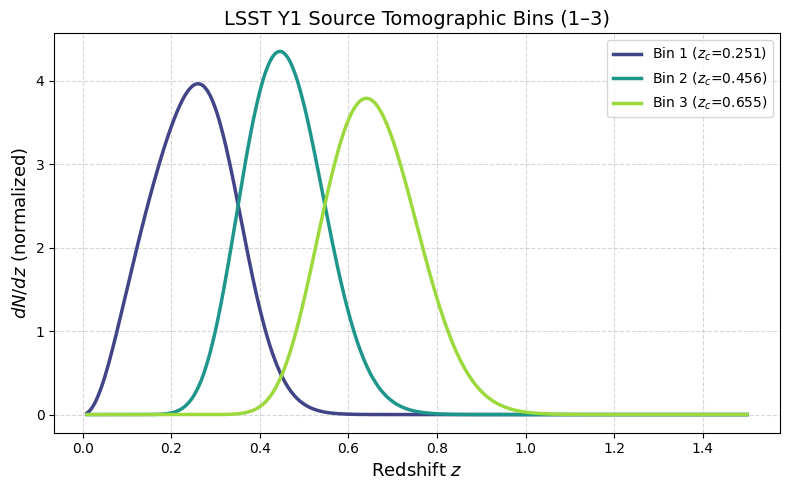

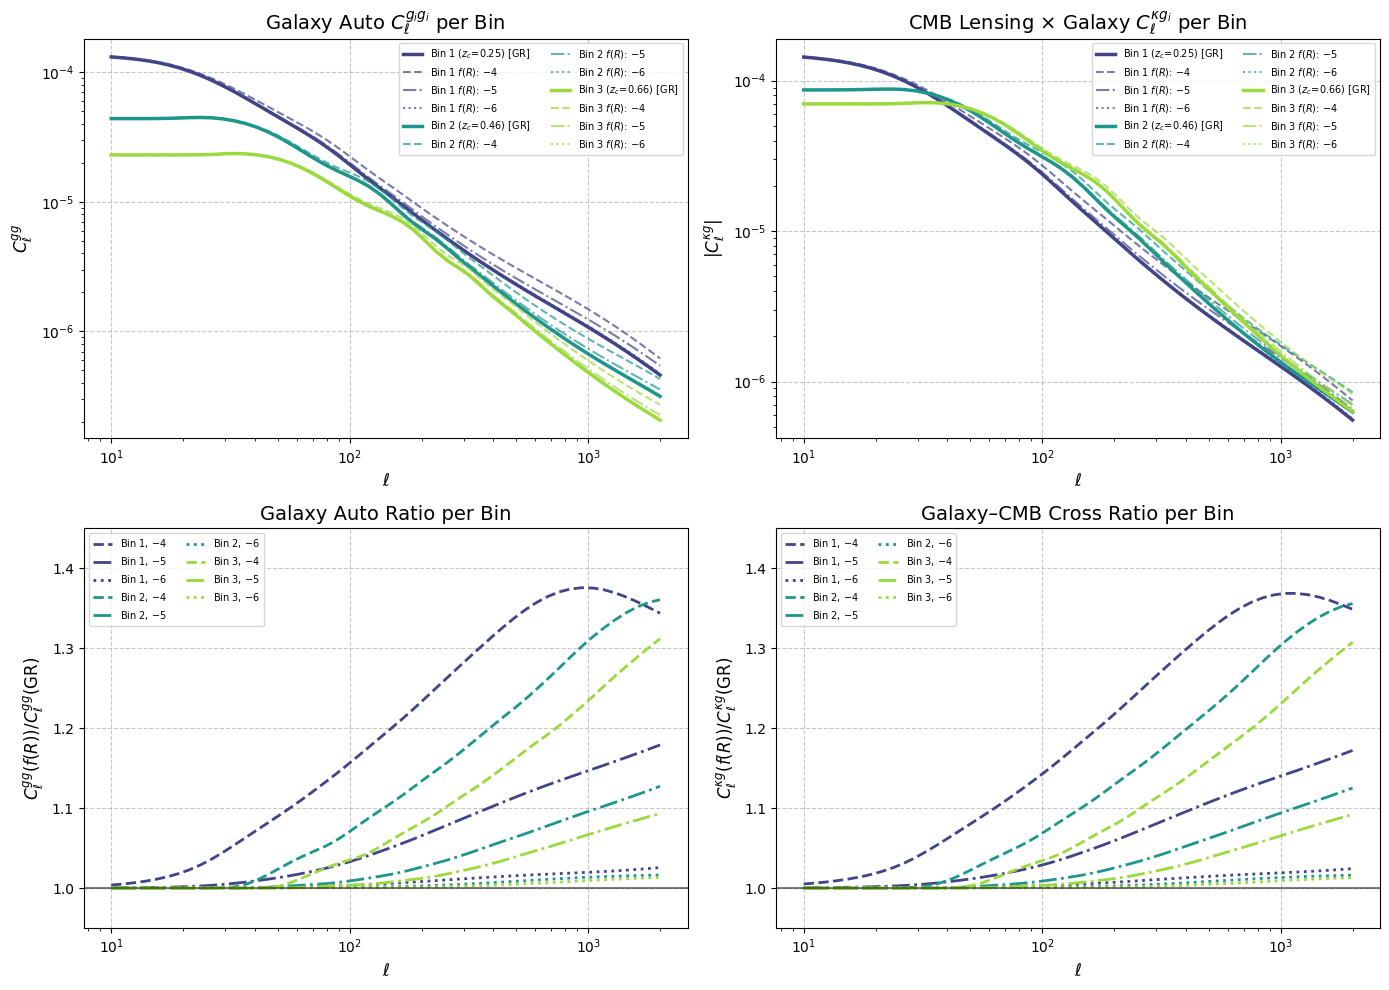

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d
from scipy.integrate import simpson, quad
import os
from contextlib import redirect_stdout, redirect_stderr
from lsst_galaxy_sample import LSSTGalaxySample as lsst

warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)


class Config:
    COSMO_PARAMS = {
        "Omega_m": 0.315,
        "Omega_b": 0.05,
        "h": 0.67,
        "n_s": 0.96,
        "sigma8": 0.83,
        "M_nu": 0.0,
        "w0": -1.0,
        "wa": 0.0,
        "aexp": 1.0
    }

    TRANSFER_FUNCTION = "boltzmann_camb"
    c = 299792.458

    Z_MIN = 0.01
    Z_MAX = 1.5           # extended to cover LSST source tails
    N_Z = 500
    Z0_GALAXY = 0.3       # kept for reference, but LSST n(z) replaces it

    ELL_MIN = 10
    ELL_MAX = 2000
    N_ELL = 50

    BIAS_B0 = 2.0

    alpha = 2.225

    FR_VALUES = [4, 5, 6]

    BACCO_K_MIN = -2
    BACCO_K_MAX = None
    BACCO_N_K = 200
    EMANTIS_VERBOSE = False

    FIGURE_SIZE = (14, 10)

    K_MIN_SAFETY = 1.1
    K_MAX_SAFETY = 0.9
    K_CLIP_THRESHOLD = 0.05

    # --- Binning configuration ---
    LSST_FORECAST_YEAR = "1"       # which LSST forecast year to use
    N_TOMO_BINS = 3                # number of tomographic bins (1-3)
    LSST_Z_RANGE_MAX = 3.5        # redshift range for LSST sample


# ============================================================
# Core Cosmological Functions (unchanged)
# ============================================================

def hubble_function(z, H0, Om_m, Om_lambda):
    return H0 * np.sqrt(
        Om_m * (1 + z)**3 +
        (1 - Om_m - Om_lambda) * (1 + z)**2 +
        Om_lambda
    )


def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    def integrand(z_prime):
        return Config.c / hubble_function(z_prime, H0, Om_m, Om_lambda)
    if np.isscalar(z):
        chi, _ = quad(integrand, 0, z)
        return chi
    else:
        return np.array([quad(integrand, 0, z_val)[0] for z_val in z])


def compute_Omega_z(z, H0, Om_m, Om_lambda):
    num = Om_m * (1 + z)**3
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den


def compute_lambda_z(z, H0, Om_m, Om_lambda):
    num = Om_lambda
    den = Om_m * (1 + z)**3 + (1 - Om_m - Om_lambda) * (1 + z)**2 + Om_lambda
    return num / den


def growth_function_g(z, H0, Om_m, Om_lambda):
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    den = Omega_z**(4/7) - lambda_z + (1 + Omega_z/2) * (1 + lambda_z/70)
    return (5 * Omega_z / 2) * (1 / den)


def growth_factor_D(z, H0, Om_m, Om_lambda):
    if np.isscalar(z):
        g_z = growth_function_g(z, H0, Om_m, Om_lambda)
        D_z_raw = g_z / (1.0 + z)
        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0
        return D_z_raw / D_0_raw
    else:
        g_z = np.array([growth_function_g(z_val, H0, Om_m, Om_lambda) for z_val in z])
        D_z_raw = g_z / (1.0 + z)
        g_0 = growth_function_g(0.0, H0, Om_m, Om_lambda)
        D_0_raw = g_0
        return D_z_raw / D_0_raw


def cmb_lensing_kernel(z, z_star, H0, Om_m, Om_lambda):
    prefactor = (3 * Om_m * H0**2) / (2 * Config.c)
    if np.isscalar(z):
        chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
        return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star
    else:
        chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
        chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)
        return prefactor * (1 + z) * chi_z * (chi_star - chi_z) / chi_star


def galaxy_lensing_kernel(z, z_array, dN_dz_func, bias_func, H0, Om_m, Om_lambda):
    bias_term = bias_func(z) * dN_dz_func(z)
    chi_z = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    def integrand(z_prime):
        chi_z_prime = comoving_distance_proper(z_prime, H0, Om_m, Om_lambda)
        return (1 - chi_z / chi_z_prime) * (Config.alpha - 1) * dN_dz_func(z_prime)
    z_star = 10.0
    integral_term, _ = quad(integrand, z, z_star)
    mu_prefactor = (3 * Om_m * H0**2) / (2 * Config.c) * (1 + z) * chi_z
    mu_z = mu_prefactor * integral_term
    return bias_term + mu_z


def bias_function(z, H0, Omega_m, Omega_lambda, b0=1.0):
    D_z = growth_factor_D(z, H0, Omega_m, Omega_lambda)
    D_0 = growth_factor_D(0, H0, Omega_m, Omega_lambda)
    D_star_z = D_z / D_0
    return b0 / (D_star_z + 1e-30)


# ============================================================
# Initialize Cosmology
# ============================================================

H0 = Config.COSMO_PARAMS["h"] * 100.0
Om_m = Config.COSMO_PARAMS["Omega_m"]
Om_lambda = 1.0 - Om_m


# ============================================================
# Power Spectrum Utilities (unchanged)
# ============================================================

def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())
            k = np.logspace(k_min, k_max, num=n_k)
    return emulator, k


def get_bacco_nonlinear_pk(emulator, params, k, aexp=1.0):
    params_bacco = {
        "omega_cold": params["Omega_m"] - params["Omega_b"],
        "sigma8_cold": params["sigma8"],
        "omega_baryon": params["Omega_b"],
        "ns": params["n_s"],
        "hubble": params["h"],
        "neutrino_mass": params.get("M_nu", 0.0),
        "w0": params.get("w0", -1.0),
        "wa": params.get("wa", 0.0),
        "expfactor": aexp
    }
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            _, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)
    return pk_nl


def initialize_emantis_emulator(verbose=False):
    return NonLinearMGBoostEmulator(verbose=verbose)


def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    params_emantis = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0
    }
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)


def create_power_spectrum_interpolator(k, pk):
    return interp1d(
        np.log(k),
        np.log(pk + 1e-50),
        kind='cubic',
        bounds_error=False,
        fill_value='extrapolate'
    )


def build_pk_interpolators_over_z(emulator, params, k, z_grid):
    pk_interps = []
    for z in z_grid:
        aexp = 1.0 / (1.0 + z)
        pk_nl = get_bacco_nonlinear_pk(emulator, params, k, aexp=aexp)
        pk_interps.append(create_power_spectrum_interpolator(k, pk_nl))
    return pk_interps


def build_pk_interpolators_over_z_fr(emulator, emantis_emu, params, logfR0, k, z_grid):
    pk_interps = []
    for z in z_grid:
        aexp = 1.0 / (1.0 + z)
        pk_gr = get_bacco_nonlinear_pk(emulator, params, k, aexp=aexp)
        pk_boost = compute_fR_boost(emantis_emu, params, logfR0, k, aexp=aexp)
        pk_fR = pk_gr * pk_boost
        pk_interps.append(create_power_spectrum_interpolator(k, pk_fR))
    return pk_interps


def check_k_bounds(k_vals, k_min, k_max, ell, spectrum_name, threshold=0.05):
    return np.clip(k_vals, k_min, k_max)


# ============================================================
# Angular Power Spectra (Limber approximation) — unchanged
# ============================================================

def compute_Cl_galaxy_auto(
    ell_array, pk_interp_list, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy auto spectrum C_ℓ^{gg} for a single bin."""
    b_vals = bias_function(z_grid, H0, Om_m, Om_lambda, b0=b0)
    Wg = b_vals * dNdz

    Cl = np.zeros_like(ell_array, dtype=float)
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^gg")
        else:
            k_safe = k_vals
        try:
            logP_kz = np.array([
                pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))
            ])
            P_kz = np.exp(logP_kz)
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10
        integrand = (H_vals / c_light) * (Wg ** 2) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)
    return Cl


def compute_Cl_galaxy_cross_bin(
    ell_array, pk_interp_list, z_grid, dNdz_i, dNdz_j,
    chi_vals, H_vals, D_vals, D0, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy cross spectrum C_ℓ^{g_i g_j} between two tomographic bins."""
    b_vals = bias_function(z_grid, H0, Om_m, Om_lambda, b0=b0)
    Wg_i = b_vals * dNdz_i
    Wg_j = b_vals * dNdz_j

    Cl = np.zeros_like(ell_array, dtype=float)
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^gg_cross")
        else:
            k_safe = k_vals
        try:
            logP_kz = np.array([
                pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))
            ])
            P_kz = np.exp(logP_kz)
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10
        integrand = (H_vals / c_light) * (Wg_i * Wg_j) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)
    return Cl


def compute_Cl_galaxy_cmb_cross(
    ell_array, pk_interp_list, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, c_light,
    H0, Om_m, Om_lambda, b0=2.0,
    k_min=None, k_max=None
):
    """Galaxy–CMB lensing cross spectrum C_ℓ^{κg} for a single bin."""
    b_vals = bias_function(z_grid, H0, Om_m, Om_lambda, b0=b0)
    Wg = b_vals * dNdz

    Cl = np.zeros_like(ell_array, dtype=float)
    for i, ell in enumerate(ell_array):
        k_vals = (ell + 0.5) / chi_vals
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^κg")
        else:
            k_safe = k_vals
        try:
            logP_kz = np.array([
                pk_interp_list[j](np.log(k_safe[j])) for j in range(len(z_grid))
            ])
            P_kz = np.exp(logP_kz)
        except ValueError:
            P_kz = np.ones_like(k_vals) * 1e-10
        integrand = (H_vals / c_light) * (Wkappa_vals * Wg) * P_kz / (chi_vals ** 2)
        Cl[i] = simpson(integrand, z_grid)
    return Cl


# ============================================================
# LSST Tomographic Binning Setup
# ============================================================

def load_lsst_source_bins(forecast_year, z_grid_lsst, n_bins=3):
    """
    Load LSST source sample and return per-bin dN/dz interpolated
    onto the computation z_grid.

    Returns
    -------
    bin_dNdz_interps : list of arrays
        Each element is dN/dz evaluated on z_grid (length N_Z),
        normalized so ∫ dN/dz dz = 1 for each bin.
    bin_centers : list of float
        Redshift center of each bin.
    total_nz : array
        Total (unbinned) normalized source n(z) on z_grid.
    """
    init = lsst(forecast_year, z_grid_lsst)
    source_bins = init.source_bins(normalized=True, save_file=False)
    source_nz = init.source_sample(normalized=True, save_file=False)
    source_bin_centers = init.source_bin_centers(decimal_places=3)

    bin_dNdz_on_zgrid = []
    bin_centers = []

    for bin_key in range(n_bins):
        # source_bins[bin_key] is defined on z_grid_lsst
        nz_bin = np.array(source_bins[bin_key])

        # Interpolate onto the computation z_grid
        interp_func = interp1d(
            z_grid_lsst, nz_bin,
            kind='linear', bounds_error=False, fill_value=0.0
        )
        bin_centers.append(source_bin_centers[bin_key])
        bin_dNdz_on_zgrid.append(interp_func)

    return bin_dNdz_on_zgrid, bin_centers, source_nz


# ============================================================
# Plotting — updated for tomographic bins
# ============================================================

def plot_binned_power_spectra(ell, Cl_gg_gr_bins, Cl_kg_gr_bins,
                              fr_results_bins=None, fR_values=None,
                              bin_centers=None, n_bins=3, figsize=(16, 12)):
    """
    Plot C_ℓ^{gg} auto (per bin), C_ℓ^{κg} (per bin),
    and f(R)/GR ratios for each bin.
    """
    from matplotlib import cm

    bin_colors = [cm.viridis(x) for x in np.linspace(0.2, 0.85, n_bins)]
    fr_linestyles = ['--', '-.', ':']

    fig, axes = plt.subplots(2, 2, figsize=figsize)

    # ---- C_ℓ^{gg} auto per bin ----
    ax = axes[0, 0]
    for b in range(n_bins):
        label = rf'Bin {b+1} ($z_c$={bin_centers[b]:.2f})' if bin_centers else f'Bin {b+1}'
        ax.loglog(ell, Cl_gg_gr_bins[b], color=bin_colors[b], linewidth=2.5, label=label + ' [GR]')

        if fr_results_bins is not None and fR_values is not None:
            for fi, logfR0_val in enumerate(fR_values):
                ax.loglog(ell, fr_results_bins["gg"][(b, b)][logfR0_val],
                          color=bin_colors[b], linestyle=fr_linestyles[fi % 3],
                          linewidth=1.5, alpha=0.7,
                          label=rf'Bin {b+1} $f(R)$: $-{logfR0_val}$')

    ax.set_xlabel(r'$\ell$', fontsize=12)
    ax.set_ylabel(r'$C_\ell^{gg}$', fontsize=12)
    ax.set_title(r'Galaxy Auto $C_\ell^{g_i g_i}$ per Bin', fontsize=14)
    ax.legend(fontsize=7, loc='best', ncol=2)
    ax.grid(True, ls='--', alpha=0.7)

    # ---- C_ℓ^{κg} per bin ----
    ax = axes[0, 1]
    for b in range(n_bins):
        label = rf'Bin {b+1} ($z_c$={bin_centers[b]:.2f})' if bin_centers else f'Bin {b+1}'
        ax.loglog(ell, np.abs(Cl_kg_gr_bins[b]), color=bin_colors[b], linewidth=2.5, label=label + ' [GR]')

        if fr_results_bins is not None and fR_values is not None:
            for fi, logfR0_val in enumerate(fR_values):
                ax.loglog(ell, np.abs(fr_results_bins["kg"][b][logfR0_val]),
                          color=bin_colors[b], linestyle=fr_linestyles[fi % 3],
                          linewidth=1.5, alpha=0.7,
                          label=rf'Bin {b+1} $f(R)$: $-{logfR0_val}$')

    ax.set_xlabel(r'$\ell$', fontsize=12)
    ax.set_ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
    ax.set_title(r'CMB Lensing $\times$ Galaxy $C_\ell^{\kappa g_i}$ per Bin', fontsize=14)
    ax.legend(fontsize=7, loc='best', ncol=2)
    ax.grid(True, ls='--', alpha=0.7)

    # ---- Ratio C_ℓ^{gg}(fR)/GR per bin ----
    ax = axes[1, 0]
    if fr_results_bins is not None and fR_values is not None:
        for b in range(n_bins):
            for fi, logfR0_val in enumerate(fR_values):
                ratio = fr_results_bins["gg"][(b, b)][logfR0_val] / Cl_gg_gr_bins[b]
                ax.semilogx(ell, ratio, color=bin_colors[b],
                            linestyle=fr_linestyles[fi % 3], linewidth=2,
                            label=rf'Bin {b+1}, $-{logfR0_val}$')
        ax.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)

    ax.set_xlabel(r'$\ell$', fontsize=12)
    ax.set_ylabel(r'$C_\ell^{gg}(f(R))/C_\ell^{gg}(\mathrm{GR})$', fontsize=12)
    ax.set_title(r'Galaxy Auto Ratio per Bin', fontsize=14)
    ax.legend(fontsize=7, loc='best', ncol=2)
    ax.grid(True, ls='--', alpha=0.7)
    ax.set_ylim([0.95, 1.45])

    # ---- Ratio C_ℓ^{κg}(fR)/GR per bin ----
    ax = axes[1, 1]
    if fr_results_bins is not None and fR_values is not None:
        for b in range(n_bins):
            for fi, logfR0_val in enumerate(fR_values):
                ratio = fr_results_bins["kg"][b][logfR0_val] / Cl_kg_gr_bins[b]
                ax.semilogx(ell, ratio, color=bin_colors[b],
                            linestyle=fr_linestyles[fi % 3], linewidth=2,
                            label=rf'Bin {b+1}, $-{logfR0_val}$')
        ax.axhline(y=1.0, color='k', linestyle='-', linewidth=1.5, alpha=0.5)

    ax.set_xlabel(r'$\ell$', fontsize=12)
    ax.set_ylabel(r'$C_\ell^{\kappa g}(f(R))/C_\ell^{\kappa g}(\mathrm{GR})$', fontsize=12)
    ax.set_title(r'Galaxy–CMB Cross Ratio per Bin', fontsize=14)
    ax.legend(fontsize=7, loc='best', ncol=2)
    ax.grid(True, ls='--', alpha=0.7)
    ax.set_ylim([0.95, 1.45])

    plt.tight_layout()
    return fig


def plot_dNdz_bins(z_grid, dNdz_bins, bin_centers, n_bins=3, figsize=(8, 5)):
    """Plot the tomographic bin dN/dz used in the computation."""
    from matplotlib import cm
    bin_colors = [cm.viridis(x) for x in np.linspace(0.2, 0.85, n_bins)]

    fig, ax = plt.subplots(figsize=figsize)
    for b in range(n_bins):
        ax.plot(z_grid, dNdz_bins[b], color=bin_colors[b], linewidth=2.5,
                label=rf'Bin {b+1} ($z_c$={bin_centers[b]:.3f})')
    ax.set_xlabel('Redshift $z$', fontsize=13)
    ax.set_ylabel(r'$dN/dz$ (normalized)', fontsize=13)
    ax.set_title(f'LSST Y{Config.LSST_FORECAST_YEAR} Source Tomographic Bins (1–{n_bins})', fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, ls='--', alpha=0.5)
    plt.tight_layout()
    return fig


# ============================================================
# Matter Power Spectra (unchanged)
# ============================================================

bacco_emu, k = initialize_bacco_emulator(
    Config.COSMO_PARAMS,
    k_min=Config.BACCO_K_MIN,
    k_max=Config.BACCO_K_MAX,
    n_k=Config.BACCO_N_K,
    verbose=Config.EMANTIS_VERBOSE
)
pk_nl_gr = get_bacco_nonlinear_pk(
    bacco_emu, Config.COSMO_PARAMS, k,
    aexp=Config.COSMO_PARAMS["aexp"]
)
pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)

emantis_emu = initialize_emantis_emulator(verbose=Config.EMANTIS_VERBOSE)


# ============================================================
# Pre-compute Redshift-Dependent Quantities
# ============================================================

z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)

# --- Load LSST tomographic bins ---
z_grid_lsst = np.linspace(0.0, Config.LSST_Z_RANGE_MAX, 500)
bin_dNdz_interp_funcs, bin_centers, total_nz_lsst = load_lsst_source_bins(
    Config.LSST_FORECAST_YEAR, z_grid_lsst, n_bins=Config.N_TOMO_BINS
)

# Evaluate each bin's dN/dz on the computation grid and re-normalize
dNdz_bins = []
for b in range(Config.N_TOMO_BINS):
    nz_on_grid = bin_dNdz_interp_funcs[b](z_grid)
    nz_on_grid = np.maximum(nz_on_grid, 0.0)  # ensure non-negative
    norm = simpson(nz_on_grid, z_grid)
    if norm > 0:
        nz_on_grid /= norm
    dNdz_bins.append(nz_on_grid)

chi_vals = comoving_distance_proper(z_grid, H0, Om_m, Om_lambda)
H_vals = hubble_function(z_grid, H0, Om_m, Om_lambda)

D_vals = growth_factor_D(z_grid, H0, Om_m, Om_lambda)
D0 = growth_factor_D(0.0, H0, Om_m, Om_lambda)

z_star = 1100.0
Wkappa_vals = cmb_lensing_kernel(z_grid, z_star, H0, Om_m, Om_lambda)

pk_interp_gr_z = build_pk_interpolators_over_z(
    bacco_emu, Config.COSMO_PARAMS, k, z_grid
)


# ============================================================
# Angular Power Spectra for GR — per tomographic bin
# ============================================================

ell = np.logspace(np.log10(Config.ELL_MIN),
                  np.log10(Config.ELL_MAX),
                  Config.N_ELL)

k_min_safe = k.min() * Config.K_MIN_SAFETY
k_max_safe = k.max() * Config.K_MAX_SAFETY

n_bins = Config.N_TOMO_BINS

# Auto spectra C_ℓ^{g_i g_i} for each bin
Cl_gg_gr_bins = []
for b in range(n_bins):
    Cl_gg = compute_Cl_galaxy_auto(
        ell, pk_interp_gr_z, z_grid, dNdz_bins[b],
        chi_vals, H_vals, D_vals, D0, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )
    Cl_gg_gr_bins.append(Cl_gg)

# Cross-bin spectra C_ℓ^{g_i g_j} (i != j)
Cl_gg_gr_cross = {}
for bi in range(n_bins):
    for bj in range(bi + 1, n_bins):
        Cl_cross = compute_Cl_galaxy_cross_bin(
            ell, pk_interp_gr_z, z_grid, dNdz_bins[bi], dNdz_bins[bj],
            chi_vals, H_vals, D_vals, D0, Config.c,
            H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
            k_min=k_min_safe, k_max=k_max_safe
        )
        Cl_gg_gr_cross[(bi, bj)] = Cl_cross

# CMB lensing × galaxy per bin: C_ℓ^{κ g_i}
Cl_kg_gr_bins = []
for b in range(n_bins):
    Cl_kg = compute_Cl_galaxy_cmb_cross(
        ell, pk_interp_gr_z, z_grid, dNdz_bins[b],
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
        H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
        k_min=k_min_safe, k_max=k_max_safe
    )
    Cl_kg_gr_bins.append(Cl_kg)


# ============================================================
# Angular Power Spectra for f(R) — per tomographic bin
# ============================================================

# Structure: fr_results_bins["gg"][(bi, bj)][logfR0] = Cl array
#            fr_results_bins["kg"][b][logfR0]          = Cl array
fr_results_bins = {"gg": {}, "kg": {}}

# Initialize nested dicts
for bi in range(n_bins):
    for bj in range(bi, n_bins):
        fr_results_bins["gg"][(bi, bj)] = {}
for b in range(n_bins):
    fr_results_bins["kg"][b] = {}

for logfR0_val in Config.FR_VALUES:
    pk_interp_fr_z = build_pk_interpolators_over_z_fr(
        bacco_emu, emantis_emu, Config.COSMO_PARAMS,
        logfR0_val, k, z_grid
    )

    # Auto spectra per bin
    for b in range(n_bins):
        Cl_gg_fr = compute_Cl_galaxy_auto(
            ell, pk_interp_fr_z, z_grid, dNdz_bins[b],
            chi_vals, H_vals, D_vals, D0, Config.c,
            H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
            k_min=k_min_safe, k_max=k_max_safe
        )
        fr_results_bins["gg"][(b, b)][logfR0_val] = Cl_gg_fr

    # Cross-bin spectra
    for bi in range(n_bins):
        for bj in range(bi + 1, n_bins):
            Cl_cross_fr = compute_Cl_galaxy_cross_bin(
                ell, pk_interp_fr_z, z_grid, dNdz_bins[bi], dNdz_bins[bj],
                chi_vals, H_vals, D_vals, D0, Config.c,
                H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
                k_min=k_min_safe, k_max=k_max_safe
            )
            fr_results_bins["gg"][(bi, bj)][logfR0_val] = Cl_cross_fr

    # CMB lensing × galaxy per bin
    for b in range(n_bins):
        Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
            ell, pk_interp_fr_z, z_grid, dNdz_bins[b],
            chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.c,
            H0, Om_m, Om_lambda, b0=Config.BIAS_B0,
            k_min=k_min_safe, k_max=k_max_safe
        )
        fr_results_bins["kg"][b][logfR0_val] = Cl_kg_fr


# ============================================================
# Plot Results
# ============================================================

# Plot the dN/dz bins
fig_nz = plot_dNdz_bins(z_grid, dNdz_bins, bin_centers,
                         n_bins=n_bins, figsize=(8, 5))
plt.show()

# Plot the angular power spectra per bin
fig = plot_binned_power_spectra(
    ell, Cl_gg_gr_bins, Cl_kg_gr_bins,
    fr_results_bins=fr_results_bins,
    fR_values=Config.FR_VALUES,
    bin_centers=bin_centers,
    n_bins=n_bins,
    figsize=Config.FIGURE_SIZE
)
plt.show()